<a href="https://colab.research.google.com/github/eldhosekroy/churn_prediction/blob/main/Churn_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Libraries**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.tokenize import sent_tokenize

#**Data Collection**

In [51]:
base_dir = os.getcwd()

input_dir = base_dir

enrolled_file = os.path.join(input_dir, 'Endrolled & registred.xlsx')
crm_file = os.path.join(input_dir, 'CRM-All contacts.xlsx')
notes_file = os.path.join(input_dir, 'All Notes-Contacts_copy.xlsx')

enrolled = pd.read_excel(enrolled_file)
crm = pd.read_excel(crm_file)
notes = pd.read_excel(notes_file)

##**Display datas**

In [52]:
enrolled.head()

,Contact Id,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Tag,...,Gender,Year of Graduation,Experience,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region,Whatsapp Number
0,zcrm_560042000000440092,zcrm_560042000000283001,SalesPerson-2,NaN,AJSAL Mohammed T S,False,NaN,NaN,Python Full stack,NaN,...,Male,NaN,NaN,False,False,Yes,NaN,NaN,NaN,NaN
1,zcrm_560042000000466061,zcrm_560042000000283001,SalesPerson-2,NaN,Abhishek R J,False,NaN,NaN,Datascience,NaN,...,Male,2022.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN
2,zcrm_560042000000565094,zcrm_560042000000331113,SalesPerson-9,Alan,Thomas,False,NaN,NaN,NaN,NaN,...,Male,2023.0,NaN,False,False,Yes,NaN,NaN,NaN,NaN
3,zcrm_560042000000583691,zcrm_560042000000331113,SalesPerson-9,NaN,Abhinav,False,NaN,NaN,NaN,Ayisha,...,Male,2023.0,NaN,False,False,Yes,NaN,NaN,NaN,NaN
4,zcrm_560042000000604837,zcrm_560042000000283001,SalesPerson-2,NaN,Albin Shaji,False,NaN,NaN,NaN,Enrolled,...,Male,2024.0,0.0,False,True,Yes,NaN,NaN,NaN,NaN


In [53]:
crm.head()

,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Description,Created Time,...,Course,Gender,Year of Graduation,Experience,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region
0,zcrm_560042000000283001,SalesPerson-2,NaN,man,False,NaN,NaN,NaN,NaN,2023-12-07 16:29:44,...,NaN,NaN,2024.0,NaN,False,False,Yes,NaN,NaN,NaN
1,zcrm_560042000000283001,SalesPerson-2,NaN,mahima,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
2,zcrm_560042000000283001,SalesPerson-2,NaN,feeba,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
3,zcrm_560042000000283001,SalesPerson-2,NaN,devadath,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
4,zcrm_560042000000283001,SalesPerson-2,NaN,keerthy,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN


In [54]:
notes.head()

,Note Id,Note Owner.id,Note Owner,Note Title,Note Content,Parent ID.id,Parent ID,Created By.id,Created By,Modified By.id,Modified By,Created Time,Modified Time
0,zcrm_560042000001333918,zcrm_560042000001286184,SalesPerson-21,NaN,SIJINA\nANOTHER CALLING,zcrm_560042000000424058,sijina,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 12:25:20,2024-05-29 12:25:20
1,zcrm_560042000001333864,zcrm_560042000001286184,SalesPerson-21,NaN,SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE,zcrm_560042000000424059,sonu,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 12:10:28,2024-05-29 12:10:28
2,zcrm_560042000001333760,zcrm_560042000001286184,SalesPerson-21,NaN,JOINED WORK,zcrm_560042000000424064,jainpaul,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 11:58:41,2024-05-29 11:58:41
3,zcrm_560042000001370043,zcrm_560042000001286184,SalesPerson-21,NaN,currently doing job,zcrm_560042000000424066,sanjeeth,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 14:35:33,2024-05-29 14:35:33
4,zcrm_560042000001333945,zcrm_560042000001286184,SalesPerson-21,NaN,SHILKA\nNOT CONNECTED,zcrm_560042000000424074,shilka,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 12:27:35,2024-05-29 12:27:35


#**Data Exploration**

In [55]:
enrolled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Id              1274 non-null   object        
 1   Contact Owner.id        1274 non-null   object        
 2   Contact Owner           1274 non-null   object        
 3   First Name              152 non-null    object        
 4   Last Name               1274 non-null   object        
 5   Email Opt Out           1274 non-null   bool          
 6   college Name.id         65 non-null     object        
 7   college Name            65 non-null     object        
 8   Track Interested        556 non-null    object        
 9   Tag                     402 non-null    object        
 10  Description             68 non-null     object        
 11  Created By.id           1274 non-null   object        
 12  Modified By.id          1274 non-null   object  

In [56]:
enrolled.describe()

,Created Time,Modified Time,Last Activity Time,Unsubscribed Mode,Unsubscribed Time,Mailing Zip,Semester,Lead Generated on,Year of Graduation,Experience,Whatsapp Number
count,1274,1274,1274,0.0,0.0,3.000000,42.000000,848,319.000000,14.000000,4.000000e+00
mean,2025-03-02 01:55:06.603610624,2025-06-04 11:53:38.827315200,2025-06-15 06:58:25.073783296,NaN,NaN,679012.000000,5.023810,2024-11-02 04:43:35.094339584,2079.304075,0.071429,8.479450e+08
min,2023-12-07 16:29:44,2024-09-25 19:25:20,2024-09-25 19:25:20,NaN,NaN,673005.000000,2.000000,2003-06-10 00:00:00,2006.000000,0.000000,7.012189e+08
25%,2024-09-05 11:19:18,2025-01-22 12:24:57.500000,2025-01-22 14:49:26,NaN,NaN,677503.000000,4.000000,2024-06-23 00:00:00,2022.000000,0.000000,7.818011e+08
50%,2025-03-25 10:36:57.500000,2025-05-19 12:46:35,2025-05-19 12:50:00,NaN,NaN,682001.000000,6.000000,2024-11-04 12:00:00,2024.000000,0.000000,8.580451e+08
75%,2025-09-02 13:42:19.500000,2025-10-15 10:38:05,2025-10-15 10:38:06,NaN,NaN,682015.500000,6.000000,2025-07-01 00:00:00,2024.000000,0.000000,9.241890e+08
max,2026-02-23 11:44:53,2026-02-23 12:05:52,2026-02-24 17:14:04,NaN,NaN,682030.000000,8.000000,2026-02-23 00:00:00,20224.000000,1.000000,9.744707e+08
std,NaN,NaN,NaN,NaN,NaN,5202.234808,1.370207,NaN,1019.109883,0.267261,1.191900e+08


In [57]:
crm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46469 entries, 0 to 46468
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Owner.id        46469 non-null  object        
 1   Contact Owner           46468 non-null  object        
 2   First Name              857 non-null    object        
 3   Last Name               46468 non-null  object        
 4   Email Opt Out           46469 non-null  bool          
 5   college Name.id         8360 non-null   object        
 6   college Name            8360 non-null   object        
 7   Track Interested        17914 non-null  object        
 8   Description             8924 non-null   object        
 9   Created Time            46469 non-null  datetime64[ns]
 10  Modified Time           46469 non-null  datetime64[ns]
 11  Last Activity Time      46162 non-null  datetime64[ns]
 12  Unsubscribed Mode       7 non-null      object

In [58]:
crm.describe()

,Created Time,Modified Time,Last Activity Time,Unsubscribed Time,Semester,Lead Generated on,Year of Graduation,Experience
count,46469,46469,46162,7,4170.000000,36338,6110.000000,641.000000
mean,2025-01-06 03:13:00.833028352,2025-05-09 08:14:01.382900224,2025-07-25 05:35:44.607837696,2025-12-03 05:27:53.571428608,7.027818,2024-07-15 01:44:25.176949760,2026.763175,34.951638
min,2023-12-07 16:29:44,2024-05-22 17:40:02,2024-05-22 17:40:02,2025-11-27 15:57:28,0.000000,1998-02-08 00:00:00,2.000000,0.000000
25%,2024-04-17 15:14:56,2024-09-25 19:57:09,2024-12-09 17:07:15.500000,2025-11-30 04:25:24,4.000000,2024-02-04 00:00:00,2023.000000,0.000000
50%,2025-02-08 10:39:42,2025-05-19 12:47:01,2025-09-30 18:25:16,2025-12-04 21:35:19,5.000000,2024-09-06 00:00:00,2024.000000,0.000000
75%,2025-08-19 12:35:45,2025-09-30 18:26:06,2026-01-23 11:00:34,2025-12-05 14:18:27,6.000000,2025-06-05 00:00:00,2025.000000,0.000000
max,2026-02-13 12:14:42,2026-02-13 12:14:42,2026-02-13 12:20:22,2025-12-08 11:14:46,2022.000000,2087-12-14 00:00:00,20224.000000,2024.000000
std,NaN,NaN,NaN,NaN,62.470446,NaN,333.541364,262.757842


In [59]:
notes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13627 entries, 0 to 13626
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Note Id         13627 non-null  object        
 1   Note Owner.id   13627 non-null  object        
 2   Note Owner      13627 non-null  object        
 3   Note Title      756 non-null    object        
 4   Note Content    13598 non-null  object        
 5   Parent ID.id    13627 non-null  object        
 6   Parent ID       13626 non-null  object        
 7   Created By.id   13627 non-null  object        
 8   Created By      13627 non-null  object        
 9   Modified By.id  13627 non-null  object        
 10  Modified By     13627 non-null  object        
 11  Created Time    13627 non-null  datetime64[ns]
 12  Modified Time   13627 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(11)
memory usage: 1.4+ MB


In [60]:
notes.describe()

,Created Time,Modified Time
count,13627,13627
mean,2025-07-01 22:25:00.722022400,2025-07-02 03:18:16.896382464
min,2023-12-13 16:49:00,2023-12-13 16:49:00
25%,2025-01-10 12:29:26.500000,2025-01-10 12:29:26.500000
50%,2025-11-14 10:13:34,2025-11-14 12:02:28
75%,2025-12-18 10:02:10.500000,2025-12-18 11:32:17
max,2026-02-13 12:18:48,2026-02-13 12:18:48


#**Data Pre-processing**

##**Data Cleaning**



*   Enrolled dataset








In [61]:
# checking null values for primary column
enrolled['Contact Id'].isnull().sum()

np.int64(0)

In [62]:
# checking duplicates values for primary column
enrolled['Contact Id'].duplicated().sum()

np.int64(0)

In [63]:
# checking duplicate values excluding contact_id column
enrolled.duplicated(subset=enrolled.columns.difference(['Contact Id'])).sum()

np.int64(0)

In [64]:
# Display the duplicate rows, considering all columns except 'Contact Id'
duplicate_rows = enrolled[enrolled.duplicated(subset=enrolled.columns.difference(['Contact Id']), keep=False)]
print(f"Number of duplicate rows (excluding 'Contact Id'): {len(duplicate_rows)}")
display(duplicate_rows.sort_values(by=list(enrolled.columns.difference(['Contact Id']))).head())

Number of duplicate rows (excluding 'Contact Id'): 0


,Contact Id,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Tag,...,Gender,Year of Graduation,Experience,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region,Whatsapp Number


In [65]:
# handling null values in different columns
# fill null values for 'invoice' column
enrolled['Invoice'] = enrolled['Invoice'].fillna('No')
enrolled['Invoice'] = enrolled['Invoice'].replace('yes', 'Yes')

# fill null values for 'program joined' column
enrolled['Program Joined'] = enrolled['Program Joined'].fillna('Not joined')

# fill null values for 'program location' column (mode)
mode_program_location = enrolled['Program Location'].mode()[0]
enrolled['Program Location'] = enrolled['Program Location'].fillna(mode_program_location)

# fill null values for 'experience' column
enrolled['Experience'] = enrolled['Experience'].fillna(0)

# fill null values for 'course' column
enrolled['Course'] = enrolled['Course'].fillna('Not mentioned')

# fill null values for 'lead generated on' column
# Sort the DataFrame by 'Lead Generated on' in ascending order
enrolled_sorted = enrolled.sort_values(by='Lead Generated on', ascending=True)
# Fill null values in 'Lead Generated on' with the previous valid date
enrolled['Lead Generated on'] = enrolled_sorted['Lead Generated on'].ffill()
# Sort back to original index order if needed (optional, often good practice)
enrolled = enrolled.sort_index()

#fill null values for 'batch assigned to' column
enrolled['Batch Assigned to'] = enrolled['Batch Assigned to'].fillna('Not assigned')

#fill null values for 'source of lead' column
mode_source_of_lead = enrolled['Source of lead'].mode()[0]
enrolled['Source of lead'] = enrolled['Source of lead'].fillna(mode_source_of_lead)

#fill null values for 'tag' column
enrolled['Tag'] = enrolled['Tag'].fillna('Not mentioned')

#fill null values for 'description' column
enrolled['Description'] = enrolled['Description'].fillna('Not mentioned')

#fill null values for 'mode of program joined' column
enrolled['Mode of Program Joined'] = enrolled['Mode of Program Joined'].fillna('Not mentioned')

In [66]:
print("Unique values and their counts in the 'Program joined' column:")
display(enrolled['Program Joined'].value_counts(dropna=False))

Unique values and their counts in the 'Program joined' column:


,count
Program Joined,
Not joined,239
Jan DA 2026,48
Aug DS 2025,40
Aug DA 2025,39
Nov DA 2025,38
...,...
Oct One Month Programme 2025,1
Jan MERN 2026,1
MERN Stack Jan25,1


In [67]:
# Standardize the 'Program Joined' column
def standardize_program_joined_text(program_string):
    if pd.isna(program_string) or program_string == 'Not joined':
        return program_string

    program_string = str(program_string)

    # 1. Standardize month names (full to short form, and ensure proper case)
    month_mapping = {
        'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
        'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
        'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
    }
    for full, short in month_mapping.items():
        program_string = re.sub(r'\b' + full + r'\b', short, program_string, flags=re.IGNORECASE)

    # Ensure month abbreviations are capitalized (e.g., "jan" -> "Jan")
    program_string = re.sub(r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b', lambda x: x.group(0).capitalize(), program_string, flags=0)

    # 2. Standardize common program keywords/abbreviations (case-insensitive search, consistent replacement)
    program_string = re.sub(r'\bprogramme\b', 'Program', program_string, flags=re.IGNORECASE)
    # Fix for 'Enrolleeee' issue: replace 'enroll' or 'enrollee' with 'Enrollee' (word boundary for accurate replacement)
    program_string = re.sub(r'\b(enroll|enrollee)\b', 'Enrollee', program_string, flags=re.IGNORECASE)

    # Specific course abbreviations - these should be uppercase
    program_string = re.sub(r'\bmern stack\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bmern\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytics\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytic\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata science\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata sci\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bfull stack\b', 'FS', program_string, flags=re.IGNORECASE)

    # Standardize 'One Month Program' variations
    program_string = re.sub(r'\b(One Month Programme|One Month Program)\b', 'One Month Program', program_string, flags=re.IGNORECASE)

    # Clean up extra spaces
    program_string = ' '.join(program_string.split())

    # Final capitalization for desired format (e.g., "DA May 2024"), then fix abbreviations
    program_string = program_string.title()
    program_string = program_string.replace('Da', 'DA').replace('Ds', 'DS').replace('Mern', 'MERN').replace('Fs', 'FS')
    # Ensure Enrollee keeps its capitalization
    program_string = program_string.replace('Enrollee', 'Enrollee')
    program_string = program_string.replace('One Month Program', 'One Month Program') # Keep as is after title()

    return program_string

# Apply this initial standardization to the 'Program Joined' column
enrolled['Program Joined'] = enrolled['Program Joined'].apply(standardize_program_joined_text)

In [68]:
print("Unique values and their counts in the 'Course' column:")
display(enrolled['Course'].value_counts(dropna=False))

Unique values and their counts in the 'Course' column:


,count
Course,
Not mentioned,861
BCA,62
Btech-IT,59
MCA,58
BCom,30
Btech-Non IT,25
MSc-IT,24
BSc-IT,20
Others,16


In [69]:
# Function to standardize course names in the 'Course' column, focusing on preserving degree names
def standardize_course_name(course_string):
    if pd.isna(course_string) or str(course_string).strip().lower() == 'not mentioned':
        return 'NOT MENTIONED'

    course_string = str(course_string).upper()

    # Remove general noise: extra spaces, some punctuation, but be careful not to remove critical parts
    # Allow A-Z, 0-9, spaces, &, and hyphens. Only allow these characters
    course_string = re.sub(r'[^-A-Z0-9\s&]', '', course_string)
    course_string = ' '.join(course_string.split()) # Normalize spaces

    # Standardize common degree and course abbreviations
    course_string = course_string.replace('B.TECH', 'BTECH')
    course_string = course_string.replace('B.E.', 'BE')
    course_string = course_string.replace('M.TECH', 'MTECH')
    course_string = course_string.replace('BSC CS', 'BSC-CS')
    course_string = course_string.replace('MSC CS', 'MSC-CS')
    course_string = course_string.replace('COMPUTER APPLICATION', 'CA')
    course_string = course_string.replace('COMPUTER SCIENCE AND ENGINEERING', 'CSE')
    course_string = course_string.replace('COMPUTER SCIENCE', 'CS')
    course_string = course_string.replace('INFORMATION TECHNOLOGY', 'IT')
    course_string = course_string.replace('DATA ANALYTICS', 'DA')
    course_string = course_string.replace('DATA SCIENCE', 'DS')
    course_string = course_string.replace('BIG DATA ANALYTICS', 'BDA')
    course_string = course_string.replace('ENGLISH LITERATURE', 'ENG LIT')
    course_string = course_string.replace('PLUS TWO', 'PLUS TWO')
    course_string = course_string.replace('DIPLOMA', 'DIPLOMA')

    # Handle common course name variations before general IT/NON-IT replacement
    course_string = course_string.replace('B TECH', 'BTECH') # For 'B TECH'
    course_string = course_string.replace('B_TECH', 'BTECH') # For 'B_TECH'
    course_string = course_string.replace('B_COM', 'BCOM') # For 'B_COM'
    course_string = course_string.replace('CA CA', 'CA') # For 'CA - CA' and 'CA CA'

    # Specific fixes for previous output issues (e.g., missing hyphens)
    course_string = course_string.replace('BTECHIT', 'BTECH-IT')
    course_string = course_string.replace('MSCIT', 'MSC-IT')
    course_string = course_string.replace('BSCIT', 'BSC-IT')
    course_string = course_string.replace('MTECHIT', 'MTECH-IT')

    # Address remaining specific MSC-CS-DA variations directly after initial replacements
    course_string = course_string.replace('MSC-CS DA', 'MSC-CS-DA')
    course_string = course_string.replace('MSC-CSDA', 'MSC-CS-DA')

    # These replacements should happen after primary acronym standardization
    # This line might create issues for standalone 'IT' if not careful. For now, keep as is as other specific replacements handle degree-IT combinations.
    course_string = course_string.replace(' IT', '-IT') # Handle BTech IT etc. to BTech-IT
    course_string = course_string.replace('NON-IT', '-NON-IT') # Handle BTech-Non IT etc.

    # Normalize hyphens: replace multiple hyphens with single, remove spaces around hyphens
    course_string = re.sub(r'-+', '-', course_string).strip('-')
    course_string = re.sub(r'\s*-\s*', '-', course_string) # Remove spaces around hyphens
    course_string = ' '.join(course_string.split()) # Final space normalization after hyphen cleanup

    # Special handling for numerical and very short entries
    if course_string == '2':
        return 'PLUS TWO'
    if course_string == 'COMP':
        return 'CS'
    if course_string == 'POST GRADUATION':
        return 'PG'
    if course_string == 'BSC SCIENCE':
        return 'BSC'
    if course_string == 'GRADUATED':
        return 'GRADUATED'
    if course_string == 'IN COLLEGE' or course_string == 'IN_COLLEGE' or course_string == 'STUDENT': # Standardize IN_COLLEGE and convert 'STUDENT' if found as a course
        return 'UNSPECIFIED' # 'STUDENT' is a role, not a course
    if course_string == 'OTHERS':
        return 'OTHERS'

    # Remove words like 'PROGRAM', 'DEGREE', 'BACHELOR', 'MASTER' if they are standalone or don't contribute to specific degree names
    # This part should be less aggressive
    course_string = re.sub(r'\b(BACHELOR|MASTER|DEGREE|PROGRAMME|PROGRAM)\b', '', course_string).strip()
    course_string = re.sub(r'\b(OF|AND)\b', '', course_string).strip() # Remove common connectors

    course_string = ' '.join(course_string.split()) # Final space normalization

    # Map common variations to desired output, e.g., 'BTECH-IT' or 'BTECH'
    if 'BTECH' in course_string and 'NON' not in course_string and 'IT' not in course_string:
        course_string = 'BTECH'
    if 'BCA' in course_string:
        course_string = 'BCA'
    if 'MCA' in course_string:
        course_string = 'MCA'
    if 'BCOM' in course_string:
        course_string = 'BCOM'
    if 'MCOM' in course_string:
        course_string = 'MCOM'
    if 'BA' in course_string and 'DA' not in course_string:
        course_string = 'BA'
    if 'MA' in course_string:
        course_string = 'MA'
    if 'BSC' in course_string and 'NON' not in course_string and 'IT' not in course_string and 'CS' not in course_string:
        course_string = 'BSC'
    if 'MSC' in course_string and 'NON' not in course_string and 'IT' not in course_string and 'CS' not in course_string:
        course_string = 'MSC'
    if 'CSE' in course_string:
        course_string = 'BTECH-CSE'
    if 'CS' in course_string and 'BSC' not in course_string and 'MSC' not in course_string:
        course_string = 'CS'

    # Ensure consistency for entries like 'BTECH-IT', 'BSC-IT', etc.
    if course_string == 'BTECH-IT':
        pass # Keep as is
    elif course_string == 'BTECH-NON-IT':
        pass # Keep as is
    elif course_string == 'BSC-IT':
        pass
    elif course_string == 'MSC-IT':
        pass
    elif course_string == 'BSC-NON-IT':
        pass
    elif course_string == 'DIPLOMA-IT':
        pass
    elif course_string == 'DIPLOMA-NON-IT':
        pass
    elif course_string == 'MSC-CS-DA':
        pass

    # Final check for empty strings or remaining generic terms
    if not course_string or course_string == 'NAN' or course_string == 'UNKNOWN' or course_string == 'UNSPECIFIED':
        return 'UNSPECIFIED'

    return course_string

enrolled['Course'] = enrolled['Course'].apply(standardize_course_name)

#**Feature Engineering**

In [70]:
# Creating new columns for easier analysis

## Extract year, month and program name
def extract_year_and_course(program_string):
    if pd.isna(program_string) or program_string == 'Not joined':
        return None, 'Not joined', None # Added None for month

    program_string = str(program_string)

    # Extract year
    year_match = re.search(r'\b(202[0-9]|203[0-9]|204[0-9])\b', program_string)
    year = int(year_match.group(1)) if year_match else None

    # Extract month (3-letter abbreviation)
    month_match = re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', program_string)
    month = month_match.group(1) if month_match else None

    cleaned_course_name = program_string
    # Remove year and month abbreviations
    cleaned_course_name = re.sub(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', '', cleaned_course_name, flags=0)
    cleaned_course_name = re.sub(r'\b(202[0-9]|203[0-9]|204[0-9])\b', '', cleaned_course_name)

    # Aggressively remove common extra words, standalone numbers, and specific unwanted patterns
    extra_words_to_remove = [
        'Program', 'Enrollee', 'One Month', 'Advanced', 'Training', 'Bootcamp', 'Course', 'Classes',
        'Online', 'Offline', 'Batch', 'Session', 'Beginner', 'Intermediate', 'Expert', 'Module'
    ]
    # Remove these words case-insensitively
    cleaned_course_name = re.sub(r'\b(' + '|'.join(extra_words_to_remove) + r')\b', '', cleaned_course_name, flags=re.IGNORECASE)

    # Remove any standalone numbers (e.g., 'DA 25' -> 'DA ') or numbers attached to words (e.g., 'DA25' -> 'DA')
    cleaned_course_name = re.sub(r'\s*\d+\s*', ' ', cleaned_course_name) # Remove standalone numbers
    cleaned_course_name = re.sub(r'\b([A-Z]+)(\d+)\b', r'\1', cleaned_course_name) # Remove trailing numbers like 'DA25'

    cleaned_course_name = re.sub(r' & ', '&', cleaned_course_name) # Standardize ampersand
    cleaned_course_name = cleaned_course_name.strip()
    cleaned_course_name = ' '.join(cleaned_course_name.split()) # Remove multiple spaces
    cleaned_course_name = cleaned_course_name.upper() # Convert to uppercase for final standardization

    final_course_name = 'UNSPECIFIED'

    # Define primary course names to recognize as prefixes, sorted by length (descending)
    primary_course_names = [
        'ROUNDED DS&GENAI PROFESSIONAL', 'GEN AI&PROMPT ENG', 'WEB DEV', 'MERN', 'FULL STACK',
        'DATA ANALYTICS', 'DATA SCIENCE', 'DS&ALGORITHMS', 'PYTHON', 'MLOPS', 'AI', 'BA', 'DM', 'ML',
        'DA', 'DS', 'FS', 'PEP', 'PY'
    ]
    primary_course_names.sort(key=len, reverse=True) # Ensure longer names are checked first

    found_primary = False
    for pc_name in primary_course_names:
        # Check if the cleaned course name starts with a primary course name, or is exactly it
        if cleaned_course_name.startswith(pc_name) or cleaned_course_name == pc_name:
            final_course_name = pc_name
            found_primary = True
            break

    # If no primary course name was found by prefix, but the cleaned_course_name is not empty, use it as is or apply specific mappings
    if not found_primary and cleaned_course_name != '':
        course_name_exact_mapping = {
            'DATA ANALYTICS': 'DA',
            'DATA SCIENCE': 'DS',
            'FULL STACK': 'FS',
            'MERN STACK': 'MERN',
            'ADVANCED': 'ADVANCED',
            'EE': 'ENROLLEE',
            'DA ENROLLEE': 'DA'
        }
        final_course_name = course_name_exact_mapping.get(cleaned_course_name, cleaned_course_name)

    # Ensure 'Churned' overrides any other logic if the original program_string was 'Churned'
    if program_string == 'Not joined':
        final_course_name = 'Not joined'
    elif final_course_name == '': # If it became empty after all processing, default to UNSPECIFIED
        final_course_name = 'UNSPECIFIED'

    return year, final_course_name, month # Updated return to include month

# Apply the year and course extraction on the newly standardized 'Program Joined Standardized' column
enrolled[['Program_Year', 'Program_Name', 'Program_Month']] = enrolled['Program Joined'].apply(lambda x: pd.Series(extract_year_and_course(x))) # Updated assignment
enrolled['Program_Month'] = enrolled['Program_Month'].fillna('NA')



## Create the 'role' column based on conditional logic
def assign_role(row):
    if row['Experience'] > 0:
        return 'Professional'
    elif row['Semester'] > 0:
        return 'Student'
    elif row['Year of Graduation'] > 0 and row['Experience'] == 0:
        # Assuming a current year for 'Idle or Career Gap' if no experience but graduated
        # For simplicity, we'll just check if they graduated and have no experience
        return 'Idle or Career Gap'
    return 'Unknown'

enrolled['role'] = enrolled.apply(assign_role, axis=1)



## Create the 'background' column based on course
def assign_background(course):
    if pd.isna(course) or course == 'NOT MENTIONED' or course == 'UNSPECIFIED':
        return 'UNKNOWN'

    # Define lists of common tech and non-tech courses
    tech_keywords = [
        'BTECH', 'BE', 'MTECH', 'BCA', 'MCA', 'BSC-CS', 'MSC-CS', 'CSE', 'CS', 'IT', 'DA', 'DS', 'BDA',
        'MSCIT', 'BSCIT', 'MTECHIT', 'MSC-CS-DA', 'BTECH-IT', 'BSC-IT', 'DIPLOMA-IT'
    ]

    non_tech_keywords = [
        'BCOM', 'MCOM', 'BA', 'MA', 'BSC', 'MSC', 'ENG LIT', 'PLUS TWO', 'DIPLOMA', 'PG',
        'BSC-NON-IT', 'DIPLOMA-NON-IT', 'GRADUATED', 'OTHERS'
    ]

    # Convert course to uppercase for case-insensitive matching
    course_upper = str(course).upper()

    for keyword in tech_keywords:
        if keyword in course_upper:
            return 'Tech'

    for keyword in non_tech_keywords:
        if keyword in course_upper:
            return 'Non-Tech'

    # If none of the above match, try to infer based on broader terms or default
    if 'TECH' in course_upper or 'SCIENCE' in course_upper or 'ENGINEERING' in course_upper:
        return 'Tech'
    elif 'ARTS' in course_upper or 'COMMERCE' in course_upper or 'HUMANITIES' in course_upper:
        return 'Non-Tech'

    return 'UNKNOWN'

enrolled['background'] = enrolled['Course'].apply(assign_background)

In [71]:
# fill null values of 'track interested' column
mode_track_interested = enrolled['Track Interested'].mode()[0]

enrolled.loc[
    enrolled['Track Interested'].isnull() & (enrolled['Program_Name'] != 'NOT JOINED'),
    'Track Interested'
] = enrolled['Program_Name']

# Fill any remaining null values in 'Track Interested' with the calculated mode
enrolled['Track Interested'] = enrolled['Track Interested'].fillna(mode_track_interested)

In [72]:
# Data type correction
float_columns = enrolled.select_dtypes(include=['float64']).columns

for col in float_columns:
    # Fill NaN values with 0 and then convert to integer
    enrolled[col] = enrolled[col].fillna(0).astype(int)

print("Data types after converting float columns to int:")
enrolled.info()

Data types after converting float columns to int:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Id              1274 non-null   object        
 1   Contact Owner.id        1274 non-null   object        
 2   Contact Owner           1274 non-null   object        
 3   First Name              152 non-null    object        
 4   Last Name               1274 non-null   object        
 5   Email Opt Out           1274 non-null   bool          
 6   college Name.id         65 non-null     object        
 7   college Name            65 non-null     object        
 8   Track Interested        1274 non-null   object        
 9   Tag                     1274 non-null   object        
 10  Description             1274 non-null   object        
 11  Created By.id           1274 non-null   object        
 12

In [73]:
# Displaying unique values for modified columns
columns_to_display = [
    'Track Interested', 'Program Joined', 'Source of lead', 'Batch Assigned to',
    'Course', 'Gender', 'Mode of Program Joined', 'Program_Year', 'Program_Month',
    'Program_Name', 'role', 'background'
]

for col in columns_to_display:
    print(f"\nUnique values for column '{col}':")
    display(enrolled[col].value_counts(dropna=False))


Unique values for column 'Track Interested':


,count
Track Interested,
DA,278
DS,247
Data Analytics,211
Datascience,189
Not joined,152
MERN,34
Data Science,29
Dataanalytics,29
MERN Stack,20



Unique values for column 'Program Joined':


,count
Program Joined,
Not joined,239
Jan DA 2026,48
Aug DS 2025,40
Aug DA 2025,39
Nov DA 2025,38
...,...
Oct One Month Program 2025,1
Jan MERN 2026,1
MERN Jan25,1



Unique values for column 'Source of lead':


...

,count
Program_Name,
DA,542
DS,426
Not joined,239
MERN,52
UNSPECIFIED,8
ROUNDED DS&GENAI PROFESSIONAL,3
PEP,2
PY,1
GEN AI&PROMPT ENG,1



Unique values for column 'role':


,count
role,
Unknown,937
Idle or Career Gap,295
Student,41
Professional,1



Unique values for column 'background':


,count
background,
UNKNOWN,874
Tech,298
Non-Tech,102


#### Operations to be done after visualization

#**Data Cleaning**

*   Notes dataset



In [74]:
# Fill null values for 'Note Title' in the notes dataset
notes['Note Title'] = notes['Note Title'].fillna('Not available')

# Fill null values for 'Note Content' in the notes dataset
notes['Note Content'] = notes['Note Content'].fillna('Not available')

#**Data Visualization and insight generation**

In [75]:
# KPI cards
total_candidates_contacted = crm.shape[0]
print(f"Total candidates contacted (number of rows in crm dataset): {total_candidates_contacted}")

Total candidates contacted (number of rows in crm dataset): 46469


In [76]:
invoice_counts = enrolled['Invoice'].value_counts()
registered_candidates = invoice_counts.get('Yes', 0)
enrolled_candidates = invoice_counts.sum()
unregistered_candidates = enrolled_candidates - registered_candidates

print("Unregistered candidates:", unregistered_candidates)
print("Registered candidates:", invoice_counts.get('Yes', 0))
print("Enrolled candidates:", invoice_counts.sum())

Unregistered candidates: 190
Registered candidates: 1084
Enrolled candidates: 1274


In [77]:
program_joined_counts = enrolled['Program Joined'].value_counts()

not_joined_candidates = program_joined_counts.get('Not joined', 0)
total_candidates = program_joined_counts.sum()
joined_candidates = total_candidates - not_joined_candidates

print("Candidates not joined in any program:", not_joined_candidates)
print("Joined candidates:", joined_candidates)

Candidates not joined in any program: 239
Joined candidates: 1035


In [78]:
program_joined_with_invoice_count = enrolled[(enrolled['Program Joined'] != 'Not joined') & (enrolled['Invoice'] == 'Yes')].shape[0]
print(f"Candidates who joined a program AND have an invoice (Active candidates): {program_joined_with_invoice_count}")

churned_program_invoice_status = enrolled[enrolled['Program Joined'] == 'Not joined']['Invoice'].value_counts()
churned_candidates = churned_program_invoice_status.get('Yes', 0)

print("Churned candidates (Invoice Yes, Program Not Joined):", churned_candidates)

churned_candidates_count = churned_program_invoice_status.get('Yes', 0)
active_candidates_count = program_joined_with_invoice_count # Updated to use program_joined_with_invoice_count

candidate_status_data = pd.Series({
    'Churned Candidates (Invoice Yes, Program not Joined)': churned_candidates_count,
    'Active Candidates (Joined Program)': active_candidates_count
})

joined_no_invoice = joined_candidates - active_candidates_count
print("Joined candidates without invoice:", joined_no_invoice)

non_active_candidates = churned_program_invoice_status.get('No', 0)
print("Inactive candidates (Invoice No, Program Not Joined):", non_active_candidates)

Candidates who joined a program AND have an invoice (Active candidates): 980
Churned candidates (Invoice Yes, Program Not Joined): 104
Joined candidates without invoice: 55
Inactive candidates (Invoice No, Program Not Joined): 135


### **Analysis of Notes Dataset**

In [79]:
# Download necessary NLTK data (run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
# Remove 'not' from stopwords to retain negation meaning
stop_words.discard('not')

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text) or text == 'Not available':
        return []
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenization
    words = [word for word in words if word not in stop_words] # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words] # Lemmatization
    return words

notes['cleaned_content'] = notes['Note Content'].apply(preprocess_text)

print("First 5 rows of notes with cleaned content:")
display(notes[['Note Content', 'cleaned_content']].head())

First 5 rows of notes with cleaned content:


,Note Content,cleaned_content
0,SIJINA\nANOTHER CALLING,"[sijina, another, calling]"
1,SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE,"[sonu, data, analytics, already, internship, d..."
2,JOINED WORK,"[joined, work]"
3,currently doing job,"[currently, job]"
4,SHILKA\nNOT CONNECTED,"[shilka, not, connected]"



20 Most Common Words in Note Content:
rnr: 3063
not: 2014
looking: 1643
da: 1525
internship: 1487
pitched: 1443
interested: 1425
d: 1199
year: 1025
call: 919
decision: 909
pending: 885
job: 809
btech: 748
month: 621
done: 609
already: 602
working: 575
course: 514
college: 510
detail: 500
fu: 497
back: 455
paid: 442
intrested: 434
c: 429
data: 404
free: 401
seems: 396
online: 375
shared: 373
update: 353
currently: 350
busy: 343
completed: 323
bca: 319
ai: 317
project: 301
python: 280
mca: 273
luminar: 267
mern: 253
science: 246
bsc: 246
session: 238
final: 237
need: 232
msc: 231
university: 230
experience: 215


/tmp/ipykernel_1649/1508714348.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=top_words_df, palette='viridis')


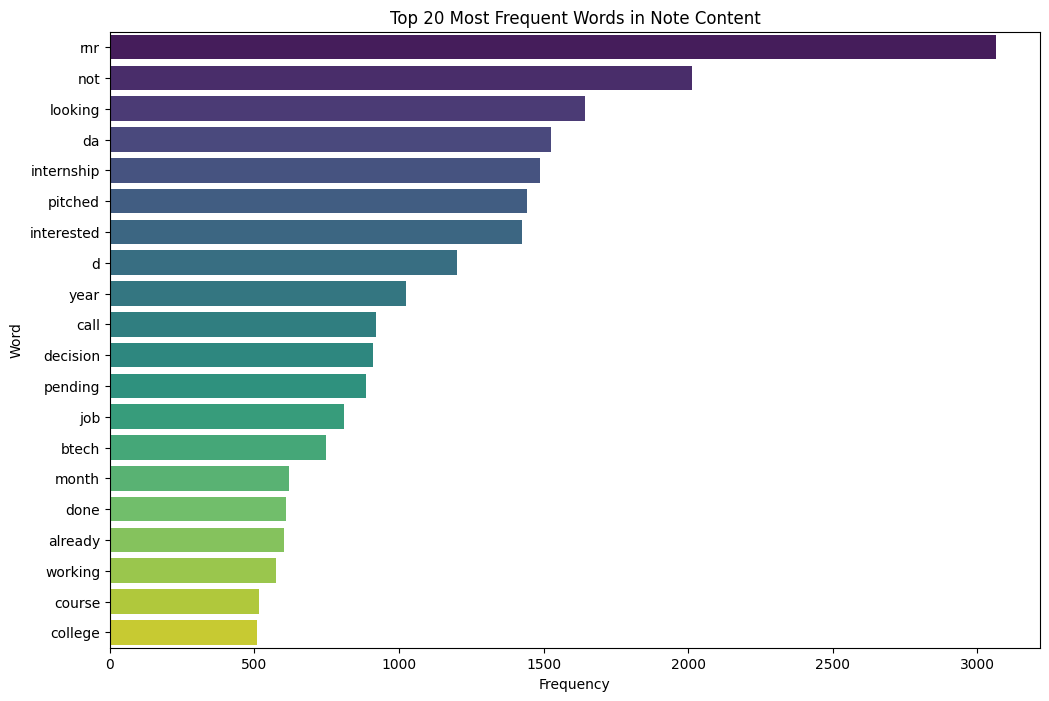

In [80]:
# word frequency analysis
# Combine all cleaned words into a single list
all_words = [word for sublist in notes['cleaned_content'] for word in sublist]

# Get the frequency of each word
word_counts = Counter(all_words)

# Display the 20 most common words
print("\n20 Most Common Words in Note Content:")
for word, count in word_counts.most_common(50):
    print(f"{word}: {count}")

# Visualize the top 20 words
top_words_df = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=top_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words in Note Content')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [81]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# frequent word context analsis
def get_sentences(text):
    if pd.isna(text) or text == 'Not available':
        return []

    text_str = str(text)

    # Replace newline characters with a period and space for better sentence tokenization
    # Handle both '\n' (literal) and '\\n' (escaped) for robustness
    processed_text = re.sub(r'\\n+', '. ', text_str) # For escaped newlines
    processed_text = re.sub(r'\n+', '. ', processed_text)  # For actual newline characters
    # Clean up multiple periods that might result from successive newlines
    processed_text = re.sub(r'\s*\.\s*\.\s*', '. ', processed_text)
    # Ensure there's a space after periods for proper tokenization
    processed_text = re.sub(r'\.(?!\s)', '. ', processed_text)

    # Tokenize the processed text into sentences
    raw_sentences = sent_tokenize(processed_text)

    cleaned_sentences = []
    for sentence in raw_sentences:
        # Clean and strip the sentence for heuristic checks
        # Temporarily remove punctuation for a more accurate 'all-caps single word' check
        cleaned_s_for_check = re.sub(r'[^a-zA-Z0-9\s]', '', sentence).strip()

        # Heuristic to filter out potential 'names' or very short non-informative phrases
        # If a sentence becomes just one word after cleaning and is all uppercase (and not just a single letter), it's likely a name.
        words = cleaned_s_for_check.split()
        if len(words) == 1 and words[0].isupper() and len(words[0]) > 1:
            continue # Filter out single, all-caps words that are likely names (e.g., 'SIJINA')

        # If the original sentence (after stripping) is meaningful, add it
        if sentence.strip():
            cleaned_sentences.append(sentence.strip())

    return cleaned_sentences

notes['sentences'] = notes['Note Content'].apply(get_sentences)

print("First 5 rows of notes with tokenized sentences:")
display(notes[['Note Content', 'sentences']].head())

First 5 rows of notes with tokenized sentences:


,Note Content,sentences
0,SIJINA\nANOTHER CALLING,[ANOTHER CALLING]
1,SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE,[DATA ANALYTICS ALREADY INTERNSHIP DONE]
2,JOINED WORK,[JOINED WORK]
3,currently doing job,[currently doing job]
4,SHILKA\nNOT CONNECTED,[NOT CONNECTED]


In [82]:
looking_sentences = []
for sentences_list in notes['sentences']:
    for sentence in sentences_list:
        if 'looking' in sentence.lower():
            looking_sentences.append(sentence)

print(f"Found {len(looking_sentences)} sentences containing 'looking'.\n")
print("Examples of sentences with 'looking':")
for i, sentence in enumerate(looking_sentences[:10]): # Display up to 10 examples
    print(f"- {sentence}")

Found 1669 sentences containing 'looking'.

Examples of sentences with 'looking':
- NOT LOOKING ANY INTRNSHIP .
- LOOKING FOR JOB ONLY
- looking for stipended internship
- NOT LOOKING FOR PAID INTERNSHIP
- LOOKING FOR JOB ONLY
- LOOKING FOR JOB ONLY
- looking for job only
- looking for job only
- looking for a free internship .
- looking for stipend internship


In [83]:
def get_context_sentences(word, df, column='sentences', num_examples=5):
    found_sentences = []
    for sentences_list in df[column]:
        for sentence in sentences_list:
            if word.lower() in sentence.lower():
                found_sentences.append(sentence)

    print(f"\n--- Context for '{word}' ---")
    print(f"Found {len(found_sentences)} sentences containing '{word}'.")
    print(f"Examples of sentences with '{word}':")
    for i, sentence in enumerate(found_sentences[:num_examples]):
        print(f"- {sentence}")

# Analyze context for 'internship'
get_context_sentences('internship', notes)

# Analyze context for 'job'
get_context_sentences('job', notes)



--- Context for 'internship' ---
Found 1438 sentences containing 'internship'.
Examples of sentences with 'internship':
- DATA ANALYTICS ALREADY INTERNSHIP DONE
- NOT INTRESTED FOR INTERNSHIP
- ALREADY DONE INTERNSHIP FROM LUMINAR .
- looking for stipended internship
- NOT LOOKING FOR PAID INTERNSHIP

--- Context for 'job' ---
Found 815 sentences containing 'job'.
Examples of sentences with 'job':
- currently doing job
- LOOKING FOR JOB ONLY
- LOOKING FOR JOB ONLY
- LOOKING FOR JOB ONLY
- looking for job only


##### **Extracting Reasons from Note Content**

In [84]:
def infer_status_and_reason_from_notes(sentences_list):
    full_note_text = ' '.join(sentences_list).lower()

    # Keywords for 'Joined' status - these should take highest precedence
    joined_keywords = [
        'enrolled', 'paid fees', 'paid the fees', 'will join today', 'registered', 'starts program',
        'course started', 'confirmed admission', 'done payment', 'admission confirmed',
        'assessment', 'assessment attended' # Added
    ]

    # --- Not Joined Reasons Keywords ---
    competitor_names_list = ['luminar', 'avodha', 'smec', 'liuminar', 'techminds', 'soften', 'techolas', 'lumimar', 'other institute', 'lum', 'excelr']
    completed_phrases_list = ['already done', 'already completed', 'already did', 'aloready completed', 'doing', 'percuing'] # Typos considered

    # Keywords for "Join Later"
    join_later_keywords = ['join later', 'will join']
    month_names = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

    # New explicit phrases for "Details Shared/Collected (Candidate)"
    candidate_details_phrases = [
        'candidate details shared', 'student details shared', 'profile details shared',
        'contact details shared', 'information shared about candidate',
        'collected candidate details', 'collected student details', 'collected profile details',
        'collected contact details', 'collected information about candidate',
        'details shared with candidate', 'details collected from candidate'
    ]

    # Check for 'Joined' status first
    for keyword in joined_keywords:
        if keyword in full_note_text:
            return 'Joined', 'N/A'

    # --- Join Later Status Logic (moved to higher precedence) ---
    if any(keyword in full_note_text for keyword in join_later_keywords):
        return 'Join Later', 'N/A'
    # Check for 'month name later' pattern
    for month in month_names:
        if re.search(r'\b' + month + r'\s+later\b', full_note_text):
            return 'Join Later', 'N/A'

    # --- Not Joined Reasons Logic ---

    # Priority 1: Specific check for 'Joined Competitor' when combined with 'already done' or 'already completed'
    found_competitor_keyword = any(comp_name in full_note_text for comp_name in competitor_names_list)
    found_completed_phrase = any(comp_phrase in full_note_text for comp_phrase in completed_phrases_list)

    if found_competitor_keyword and found_completed_phrase:
        return 'Not Joined', 'Joined Competitor'

    # Priority 2: Other 'Not Joined' reasons
    not_joined_reasons = {
        'Joined Competitor': [
            'lum', 'luminar', 'avodha', 'excelr', 'smec', 'liuminar', 'techminds', 'soften', 'joined competitor', 'other institute', 'lumimar', 'techolas'
        ],
        'Already Working/Internship': [
            'already working', 'already job', 'technopark', 'infopark', 'doing job', 'doing internship', 'working experience', 'placed', 'joined work', 'already internship done', 'currently working',
            'working as a',
            *completed_phrases_list # Unpack the phrases here if they are not with competitor
        ],
        'Looking for Job/Internship (Specific Type)': [
            'looking for job', 'job only', 'looking for internship', 'internship only',
            'looking for stipend', 'free internship'
        ],
        'Not Interested': [
            'not interested', 'no interest', 'not joining', 'not join', 'not intrested for internship'
        ],
        'Financial Issue': [
            'fees', 'amount issue', 'money issue', 'expensive', 'cost', 'financial issue', 'fee issue'
        ],
        'Unreachable/Not Connected': [
            'not connected', 'unreachable', 'no network', 'switched off', 'rnr', 'wrong number', 'unanswered', 'no response', 'unresponsive', 'call later', 'not answering',
            'not responding', 'dis call', 'not reachable', 'nc', 'busy', 'call not connected', 'disconnected', 'switch off', 'incoming calls', 'incoming not', 'junk',
            'na', 'invalid', 'rejected', 'not respond', 'out of service', 'wrong number', 'incoming', 'not connecting', 'voice mail', 'voice issue', 'bc', 'wrong no',
            'network issue', 'out of network', 'rhr', 'disconnecting', 'blocked', 'r rn', 'rne', 'not attended', 'callbusy', 'not ringing', 'discall'
        ],
        'Decision Pending/Discussing': [
            'decision pending', 'thinking', 'will inform', 'call back', 'discuss with family', 'discuss with parents'
        ],
        'Location Issue': [
            'location issue', 'migrate', 'relocate', 'far away', 'different city'
        ],
        'Time/Schedule Conflict': [
            'time issue', 'schedule conflict', 'busy', 'clash'
        ]
    }

    for reason, keywords in not_joined_reasons.items():
        for keyword in keywords:
            if keyword in full_note_text:
                if reason == 'Looking for Job/Internship (Specific Type)' and any(ni_key in full_note_text for ni_key in ['not interested', 'no interest']):
                    return 'Not Joined', 'Looking for Other Opportunity (Not Interested)'
                return 'Not Joined', reason

    # --- Unclear Status Logic ---
    # Handle "Details Shared/Collected (Candidate)" with explicit phrases
    if any(phrase in full_note_text for phrase in candidate_details_phrases):
        return 'Unclear', 'Details Shared/Collected (Candidate)'


    # If neither joined nor a clear not-joined reason, check for general interest/pending
    if 'interested' in full_note_text or 'enquiring' in full_note_text or 'waiting' in full_note_text:
        return 'Unclear', 'Interested/Pending'

    # Default to 'Unclear' if no definitive status or reason found
    return 'Unclear', 'Other/Unspecified'


# Apply the new function to the notes DataFrame
notes[['inferred_status', 'inferred_reason']] = notes['sentences'].apply(lambda x: pd.Series(infer_status_and_reason_from_notes(x)))

print("First 50 notes with inferred status and reason:")
display(notes[['Note Content', 'inferred_status', 'inferred_reason']].head(50))

print("\nInferred Status distribution:")
display(notes['inferred_status'].value_counts())

First 50 notes with inferred status and reason:


,Note Content,inferred_status,inferred_reason
0,SIJINA\nANOTHER CALLING,Unclear,Other/Unspecified
1,SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE,Not Joined,Already Working/Internship
2,JOINED WORK,Not Joined,Already Working/Internship
3,currently doing job,Not Joined,Already Working/Internship
4,SHILKA\nNOT CONNECTED,Not Joined,Unreachable/Not Connected
5,VISHNU CALL NOT ANSWERING,Not Joined,Unreachable/Not Connected
6,RESOURCE \nPLUS TWO\n2017\nBACKERY SHOP\nIDUKK...,Unclear,Other/Unspecified
7,software testing from liuminar and pfs from av...,Not Joined,Joined Competitor
8,datascience from techminds,Not Joined,Joined Competitor
9,bigdata from lumimar,Not Joined,Joined Competitor



Inferred Status distribution:


,count
inferred_status,
Not Joined,7798
Unclear,5669
Joined,80
Join Later,80


In [86]:
print("\nInferred Reason distribution for all notes:")
display(notes['inferred_reason'].value_counts())


Inferred Reason distribution for all notes:


,count
inferred_reason,
Other/Unspecified,5374
Unreachable/Not Connected,4026
Already Working/Internship,1002
Decision Pending/Discussing,860
Not Interested,753
Joined Competitor,579
Looking for Job/Internship (Specific Type),489
Interested/Pending,295
N/A,160


Number of notes inferred as 'Not Joined': 7798

Inferred Reasons for Not Joining:


,Reason,Count
0,Unreachable/Not Connected,4026
1,Already Working/Internship,1002
2,Decision Pending/Discussing,860
3,Not Interested,753
4,Joined Competitor,579
5,Looking for Job/Internship (Specific Type),489
6,Financial Issue,39
7,Looking for Other Opportunity (Not Interested),39
8,Location Issue,9
9,Time/Schedule Conflict,2


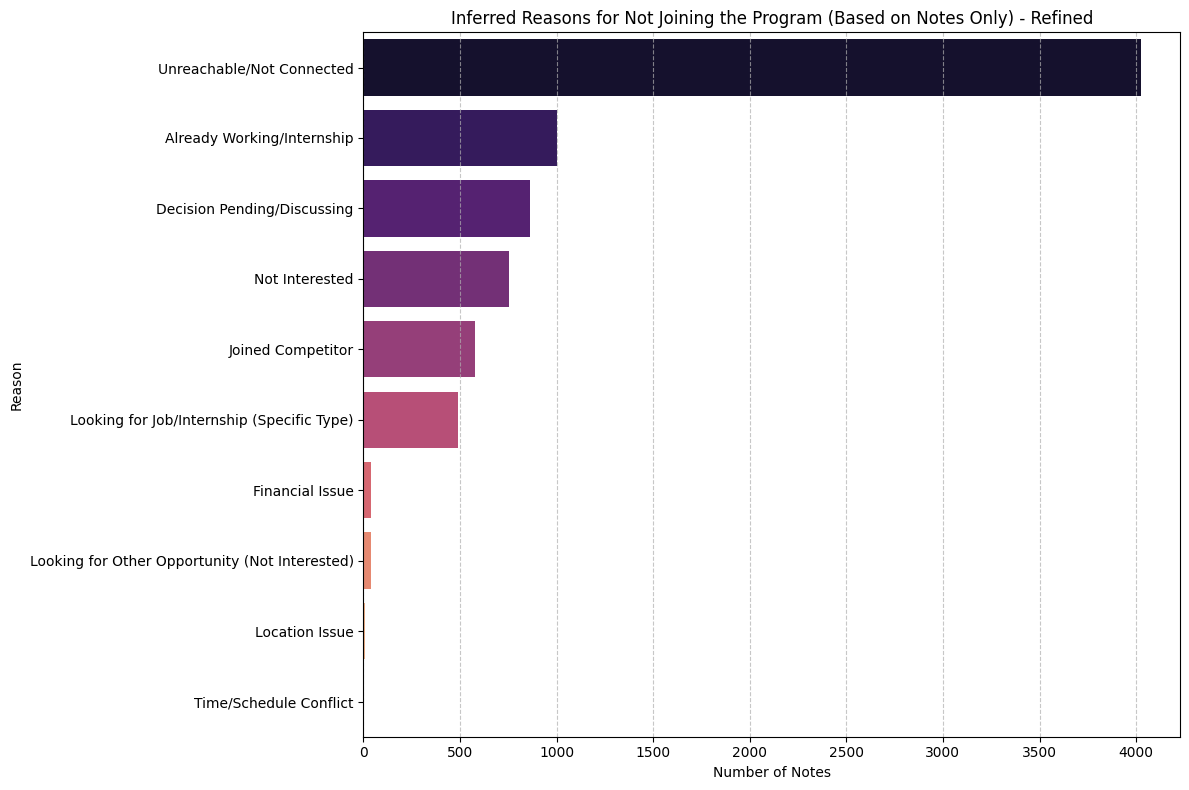

In [87]:
notes_non_joiners_inferred = notes[notes['inferred_status'] == 'Not Joined'].copy()

print(f"Number of notes inferred as 'Not Joined': {len(notes_non_joiners_inferred)}")

# Get value counts for inferred reasons
inferred_reason_counts = notes_non_joiners_inferred['inferred_reason'].value_counts().reset_index()
inferred_reason_counts.columns = ['Reason', 'Count']

print("\nInferred Reasons for Not Joining:")
display(inferred_reason_counts)

# Visualize the inferred reasons
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Reason', data=inferred_reason_counts, palette='magma', hue='Reason', legend=False) # Added hue for clarity
plt.title('Inferred Reasons for Not Joining the Program (Based on Notes Only) - Refined')
plt.xlabel('Number of Notes')
plt.ylabel('Reason')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [88]:
# analysis to find whether candidate attended induction section
induction_keywords = ['induction', 'onboarding', 'orientation', 'joining process', 'join date', 'commencement']

for keyword in induction_keywords:
    get_context_sentences(keyword, notes, num_examples=5)


--- Context for 'induction' ---
Found 0 sentences containing 'induction'.
Examples of sentences with 'induction':

--- Context for 'onboarding' ---
Found 0 sentences containing 'onboarding'.
Examples of sentences with 'onboarding':

--- Context for 'orientation' ---
Found 0 sentences containing 'orientation'.
Examples of sentences with 'orientation':

--- Context for 'joining process' ---
Found 0 sentences containing 'joining process'.
Examples of sentences with 'joining process':

--- Context for 'join date' ---
Found 0 sentences containing 'join date'.
Examples of sentences with 'join date':

--- Context for 'commencement' ---
Found 0 sentences containing 'commencement'.
Examples of sentences with 'commencement':


###**Analysis of enrolled dataset**

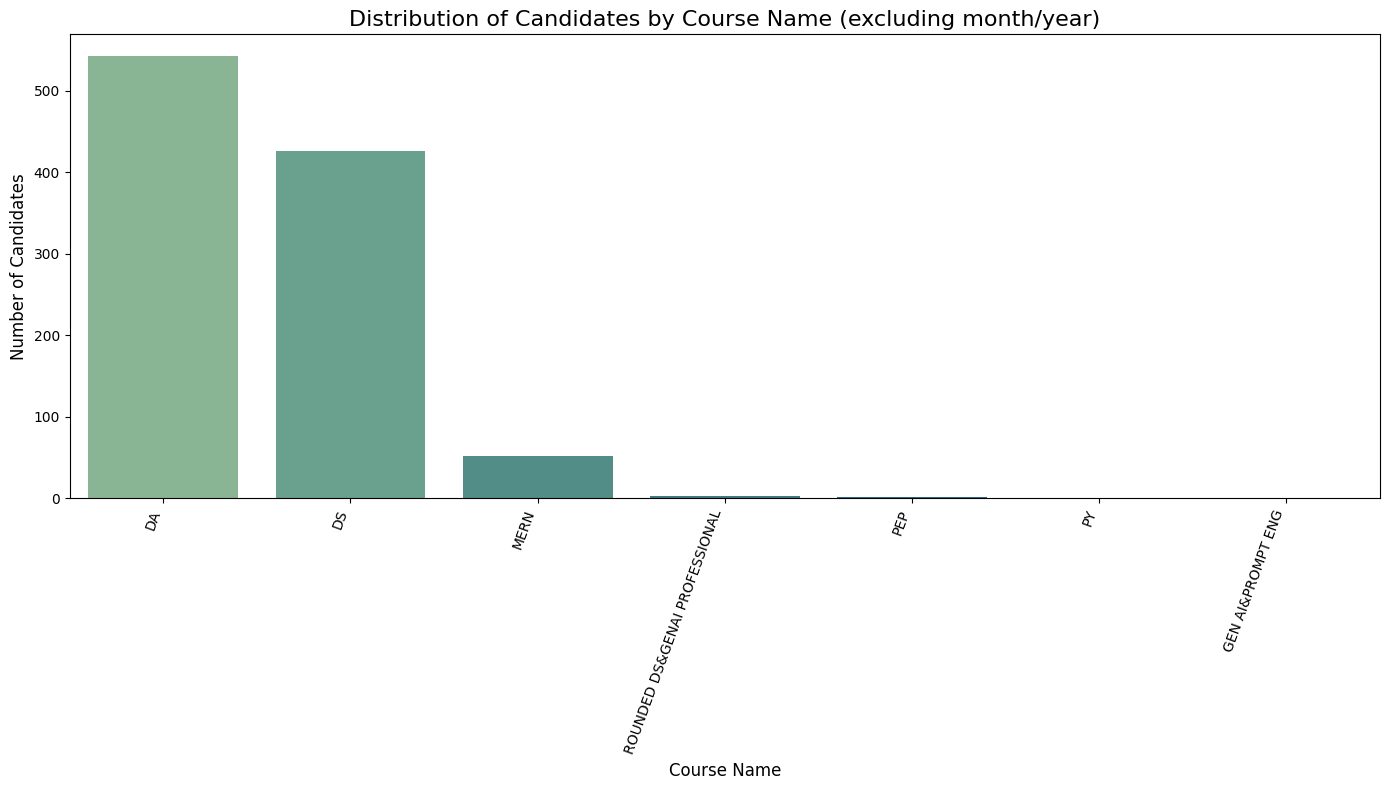

In [89]:
program_name_distribution = enrolled[(enrolled['Program_Name'] != 'Not joined') & (enrolled['Program_Name'] != 'UNSPECIFIED')]
program_name_counts = program_name_distribution['Program_Name'].value_counts()

plt.figure(figsize=(14, 8)) # Increased figure size
sns.barplot(x=program_name_counts.index, y=program_name_counts.values, hue=program_name_counts.index, palette='crest', legend=False)
plt.title('Distribution of Candidates by Course Name (excluding month/year)', fontsize=16)
plt.xlabel('Course Name', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=70, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Candidates who joined a program AND have an invoice (Active candidates): 980
Churned candidates (Invoice Yes, Program Joined Churned): 104
Joined candidates without invoice: 55
Inactive candidates (Invoice No, Program Joined Churned): 135


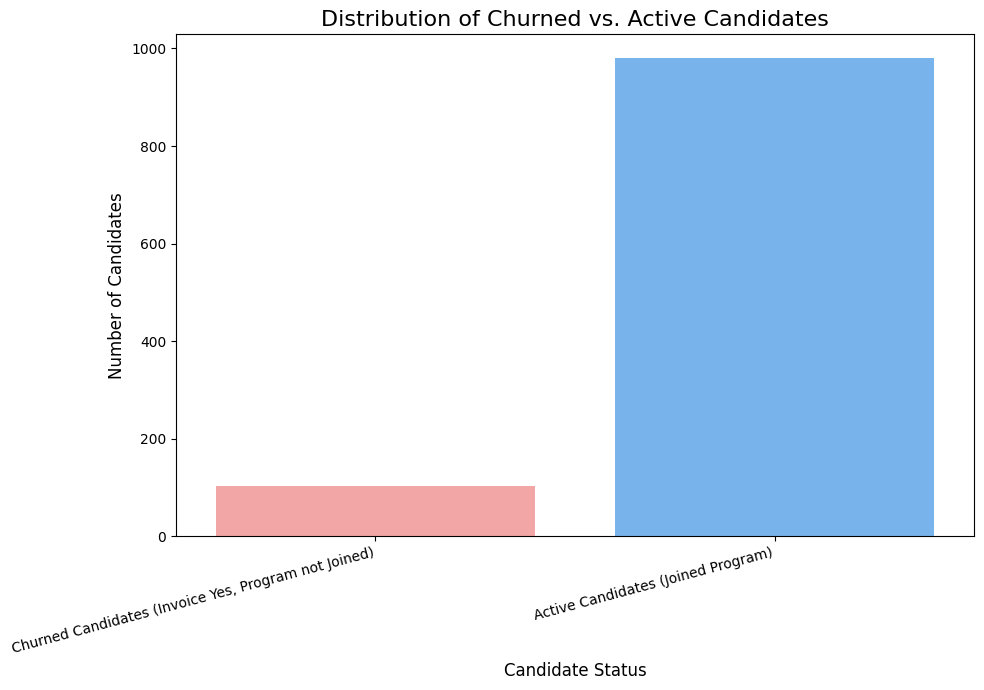

In [90]:
program_joined_with_invoice_count = enrolled[(enrolled['Program Joined'] != 'Not joined') & (enrolled['Invoice'] == 'Yes')].shape[0]
print(f"Candidates who joined a program AND have an invoice (Active candidates): {program_joined_with_invoice_count}")

churned_program_invoice_status = enrolled[enrolled['Program Joined'] == 'Not joined']['Invoice'].value_counts()
churned_candidates = churned_program_invoice_status.get('Yes', 0)

print("Churned candidates (Invoice Yes, Program Joined Churned):", churned_candidates)

churned_candidates_count = churned_program_invoice_status.get('Yes', 0)
active_candidates_count = program_joined_with_invoice_count # Updated to use program_joined_with_invoice_count

candidate_status_data = pd.Series({
    'Churned Candidates (Invoice Yes, Program not Joined)': churned_candidates_count,
    'Active Candidates (Joined Program)': active_candidates_count
})

joined_no_invoice = joined_candidates - active_candidates_count
print("Joined candidates without invoice:", joined_no_invoice)

non_active_candidates = churned_program_invoice_status.get('No', 0)
print("Inactive candidates (Invoice No, Program Joined Churned):", non_active_candidates)


plt.figure(figsize=(10, 7))
sns.barplot(x=candidate_status_data.index, y=candidate_status_data.values, hue=candidate_status_data.index, palette=['#ff9999', '#66b3ff'], legend=False)
plt.title('Distribution of Churned vs. Active Candidates', fontsize=16)
plt.xlabel('Candidate Status', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

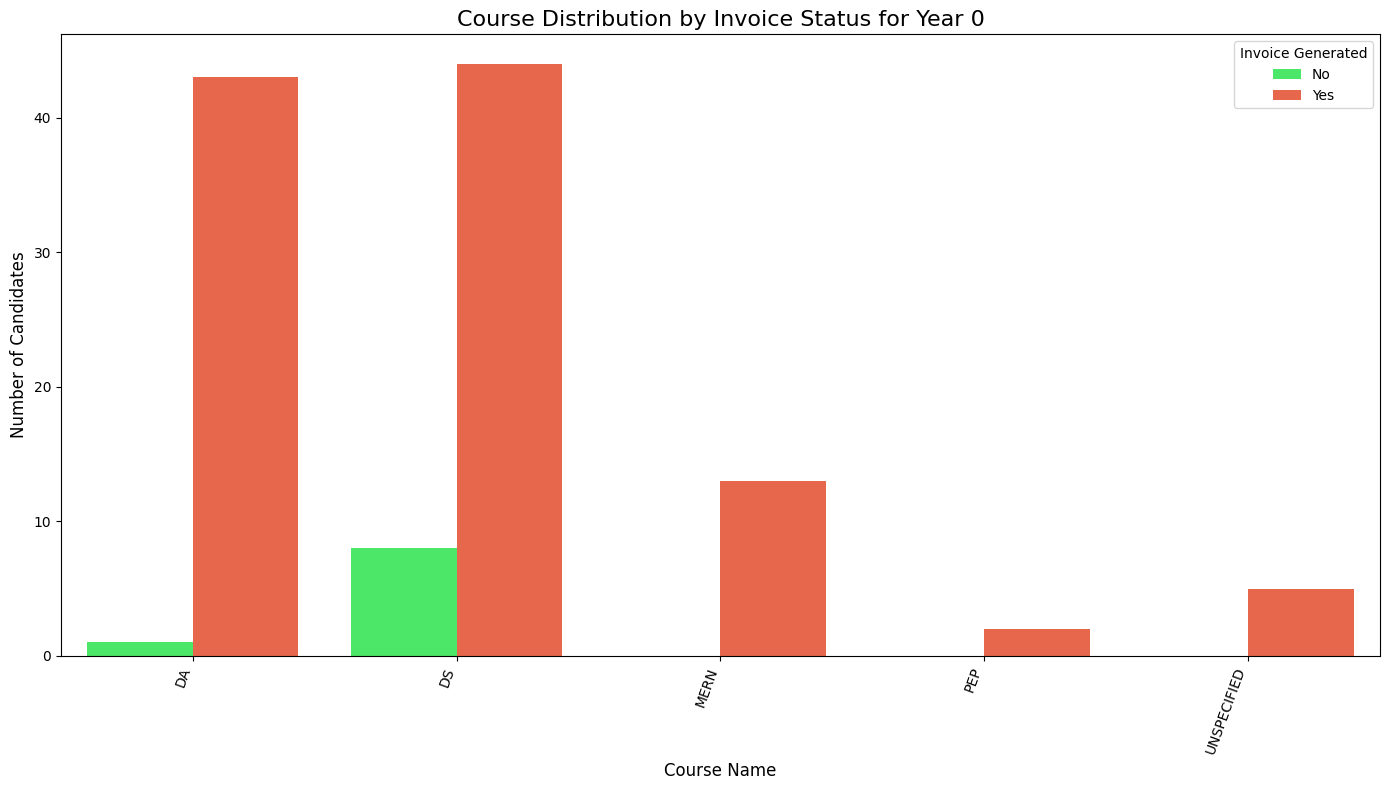

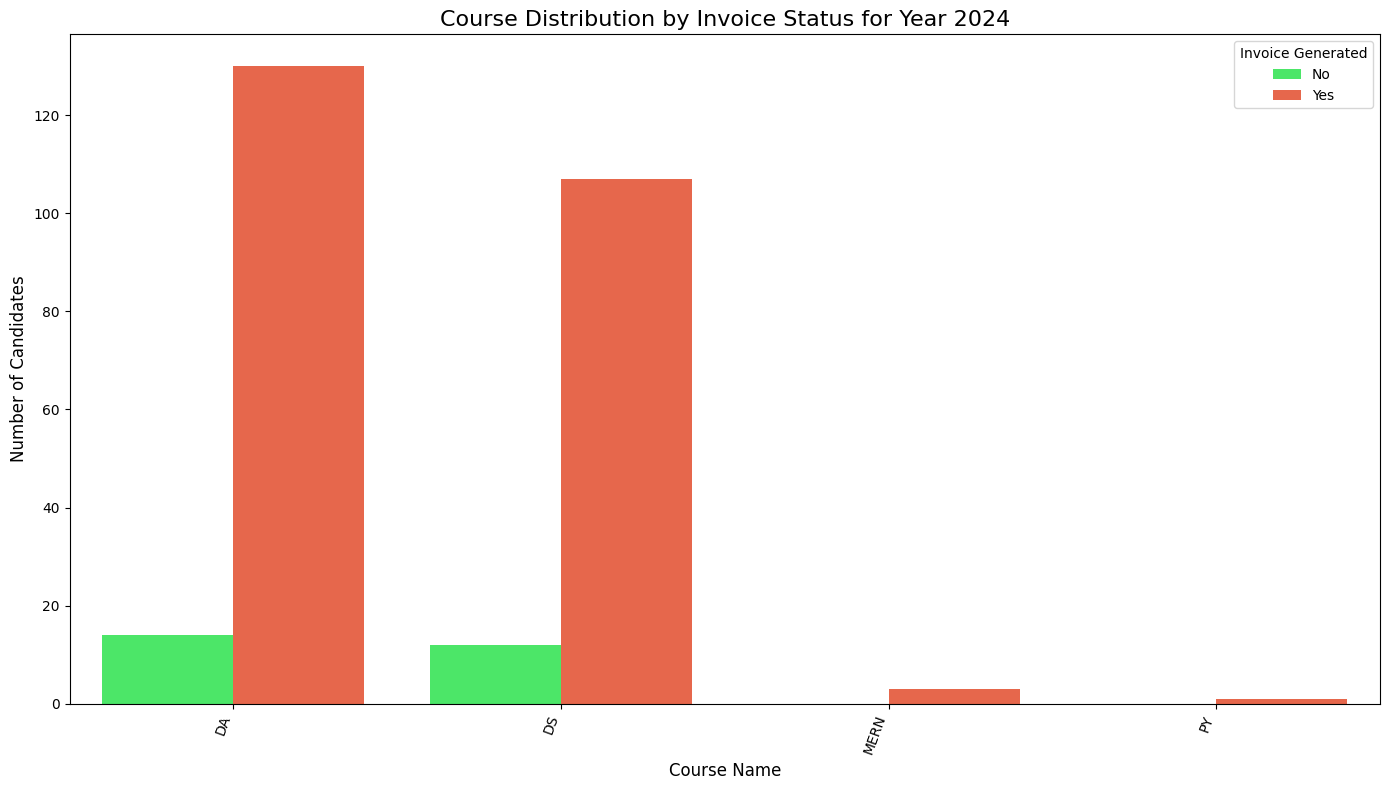

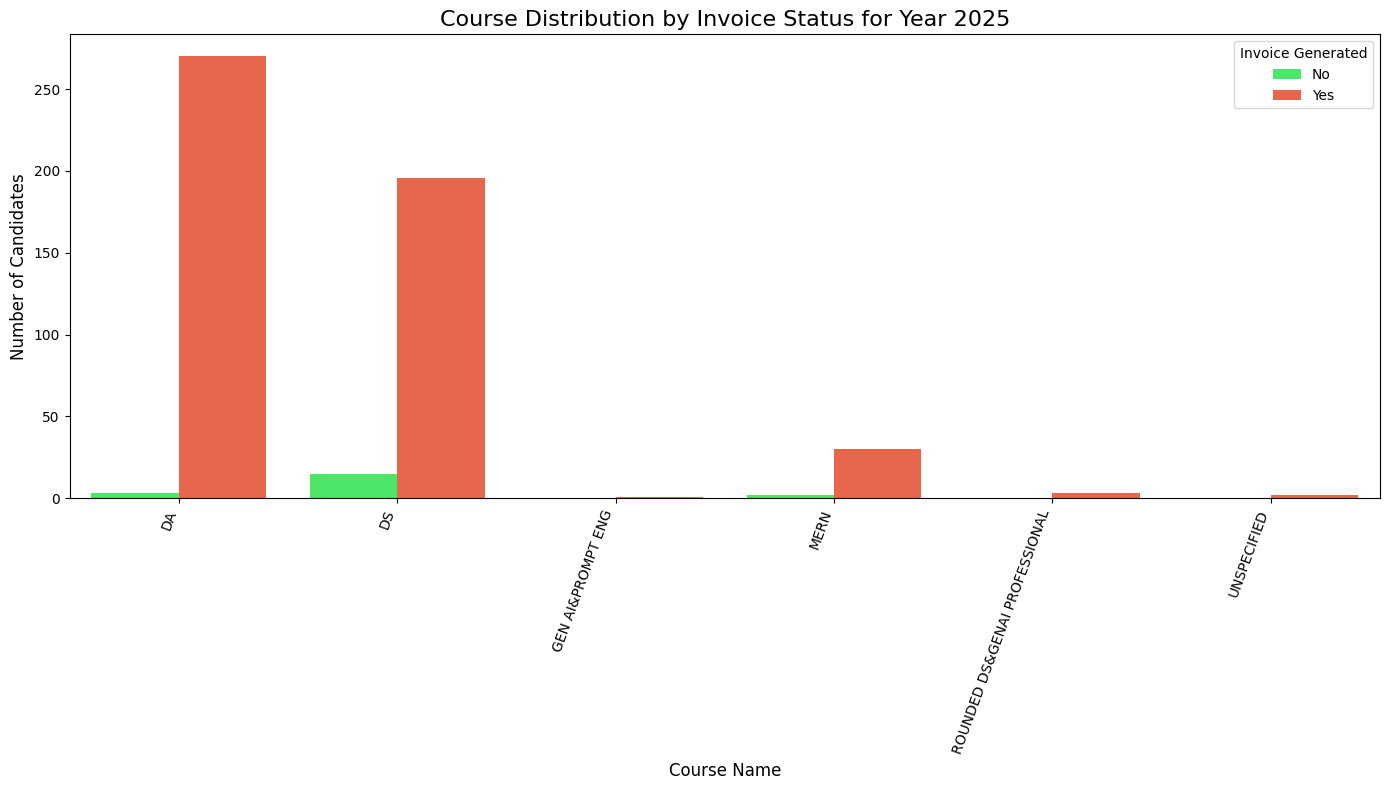

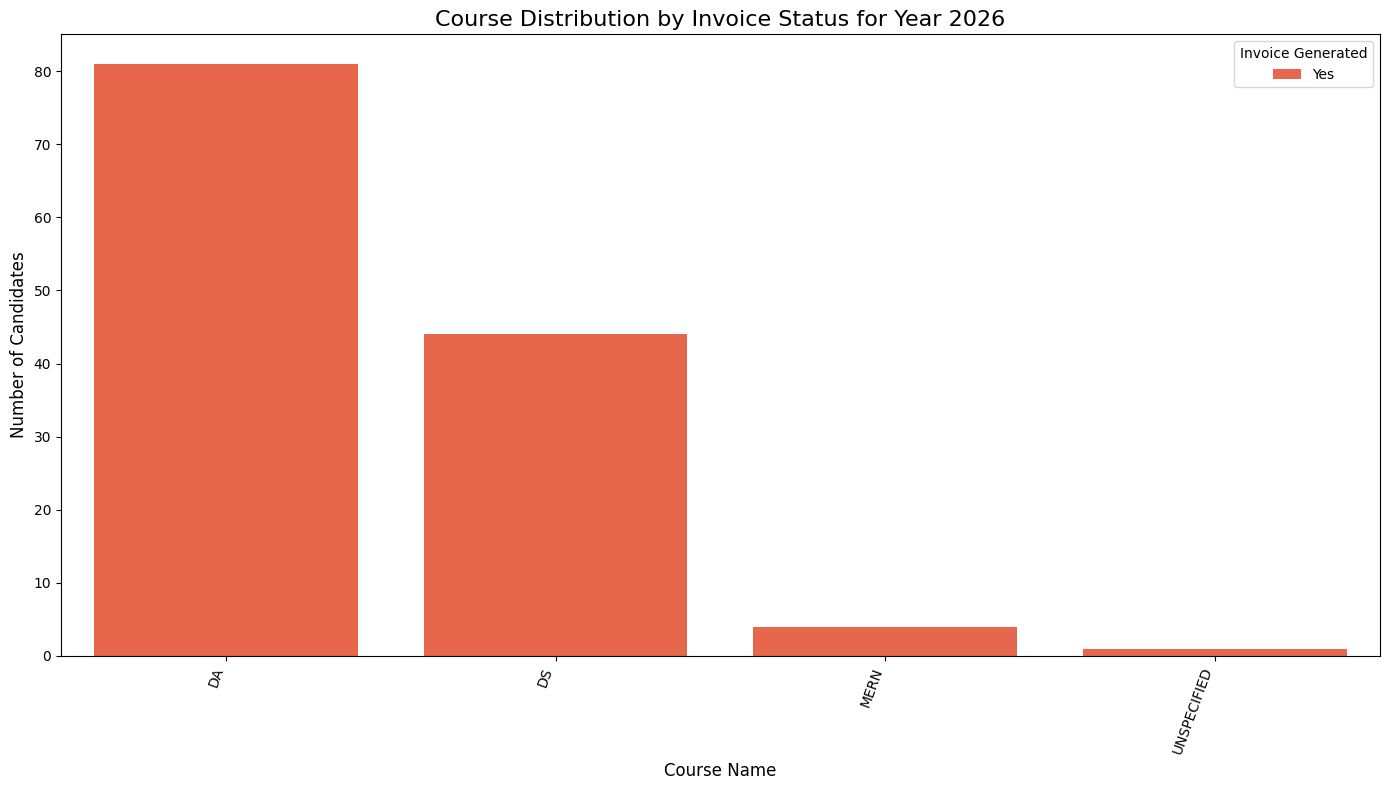

In [91]:
# Filter out 'Churned' courses and entries with NaN years for visualization
# Assuming 'enrolled' DataFrame, 'Course_Name', 'Program_Year', and 'Invoice' are already prepared from previous steps.
program_data_for_plot = enrolled[enrolled['Program_Name'] != 'Not joined'].dropna(subset=['Program_Year']).copy()
program_data_for_plot['Program_Year'] = program_data_for_plot['Program_Year'].astype(int)

# Get unique years for plotting
unique_years_for_plot = sorted(program_data_for_plot['Program_Year'].unique())

for year in unique_years_for_plot:
    year_data = program_data_for_plot[program_data_for_plot['Program_Year'] == year]

    # Group by Course_Name and Invoice status, then count
    course_invoice_counts = year_data.groupby(['Program_Name', 'Invoice']).size().unstack(fill_value=0)

    if not course_invoice_counts.empty:
        # Prepare data for seaborn.barplot with hue
        # 'level_1' is the default name for the stacked column if no other name is specified. It corresponds to 'Invoice'.
        plot_df = course_invoice_counts.stack().reset_index(name='Count')

        plt.figure(figsize=(14, 8)) # Increased figure size for better readability
        sns.barplot(
            data=plot_df,
            x='Program_Name',
            y='Count',
            hue='Invoice', # Use the 'Invoice' column directly for hue
            palette={'Yes': '#FF5733', 'No': '#33FF57'} # Using brighter, more distinct colors
        )
        plt.title(f'Course Distribution by Invoice Status for Year {year}', fontsize=16)
        plt.xlabel('Course Name', fontsize=12)
        plt.ylabel('Number of Candidates', fontsize=12)
        plt.xticks(rotation=70, ha='right')
        plt.legend(title='Invoice Generated') # Add a legend for Invoice Status
        plt.tight_layout()
        plt.show()
    else:
        print(f'No course data available for year {year}.')


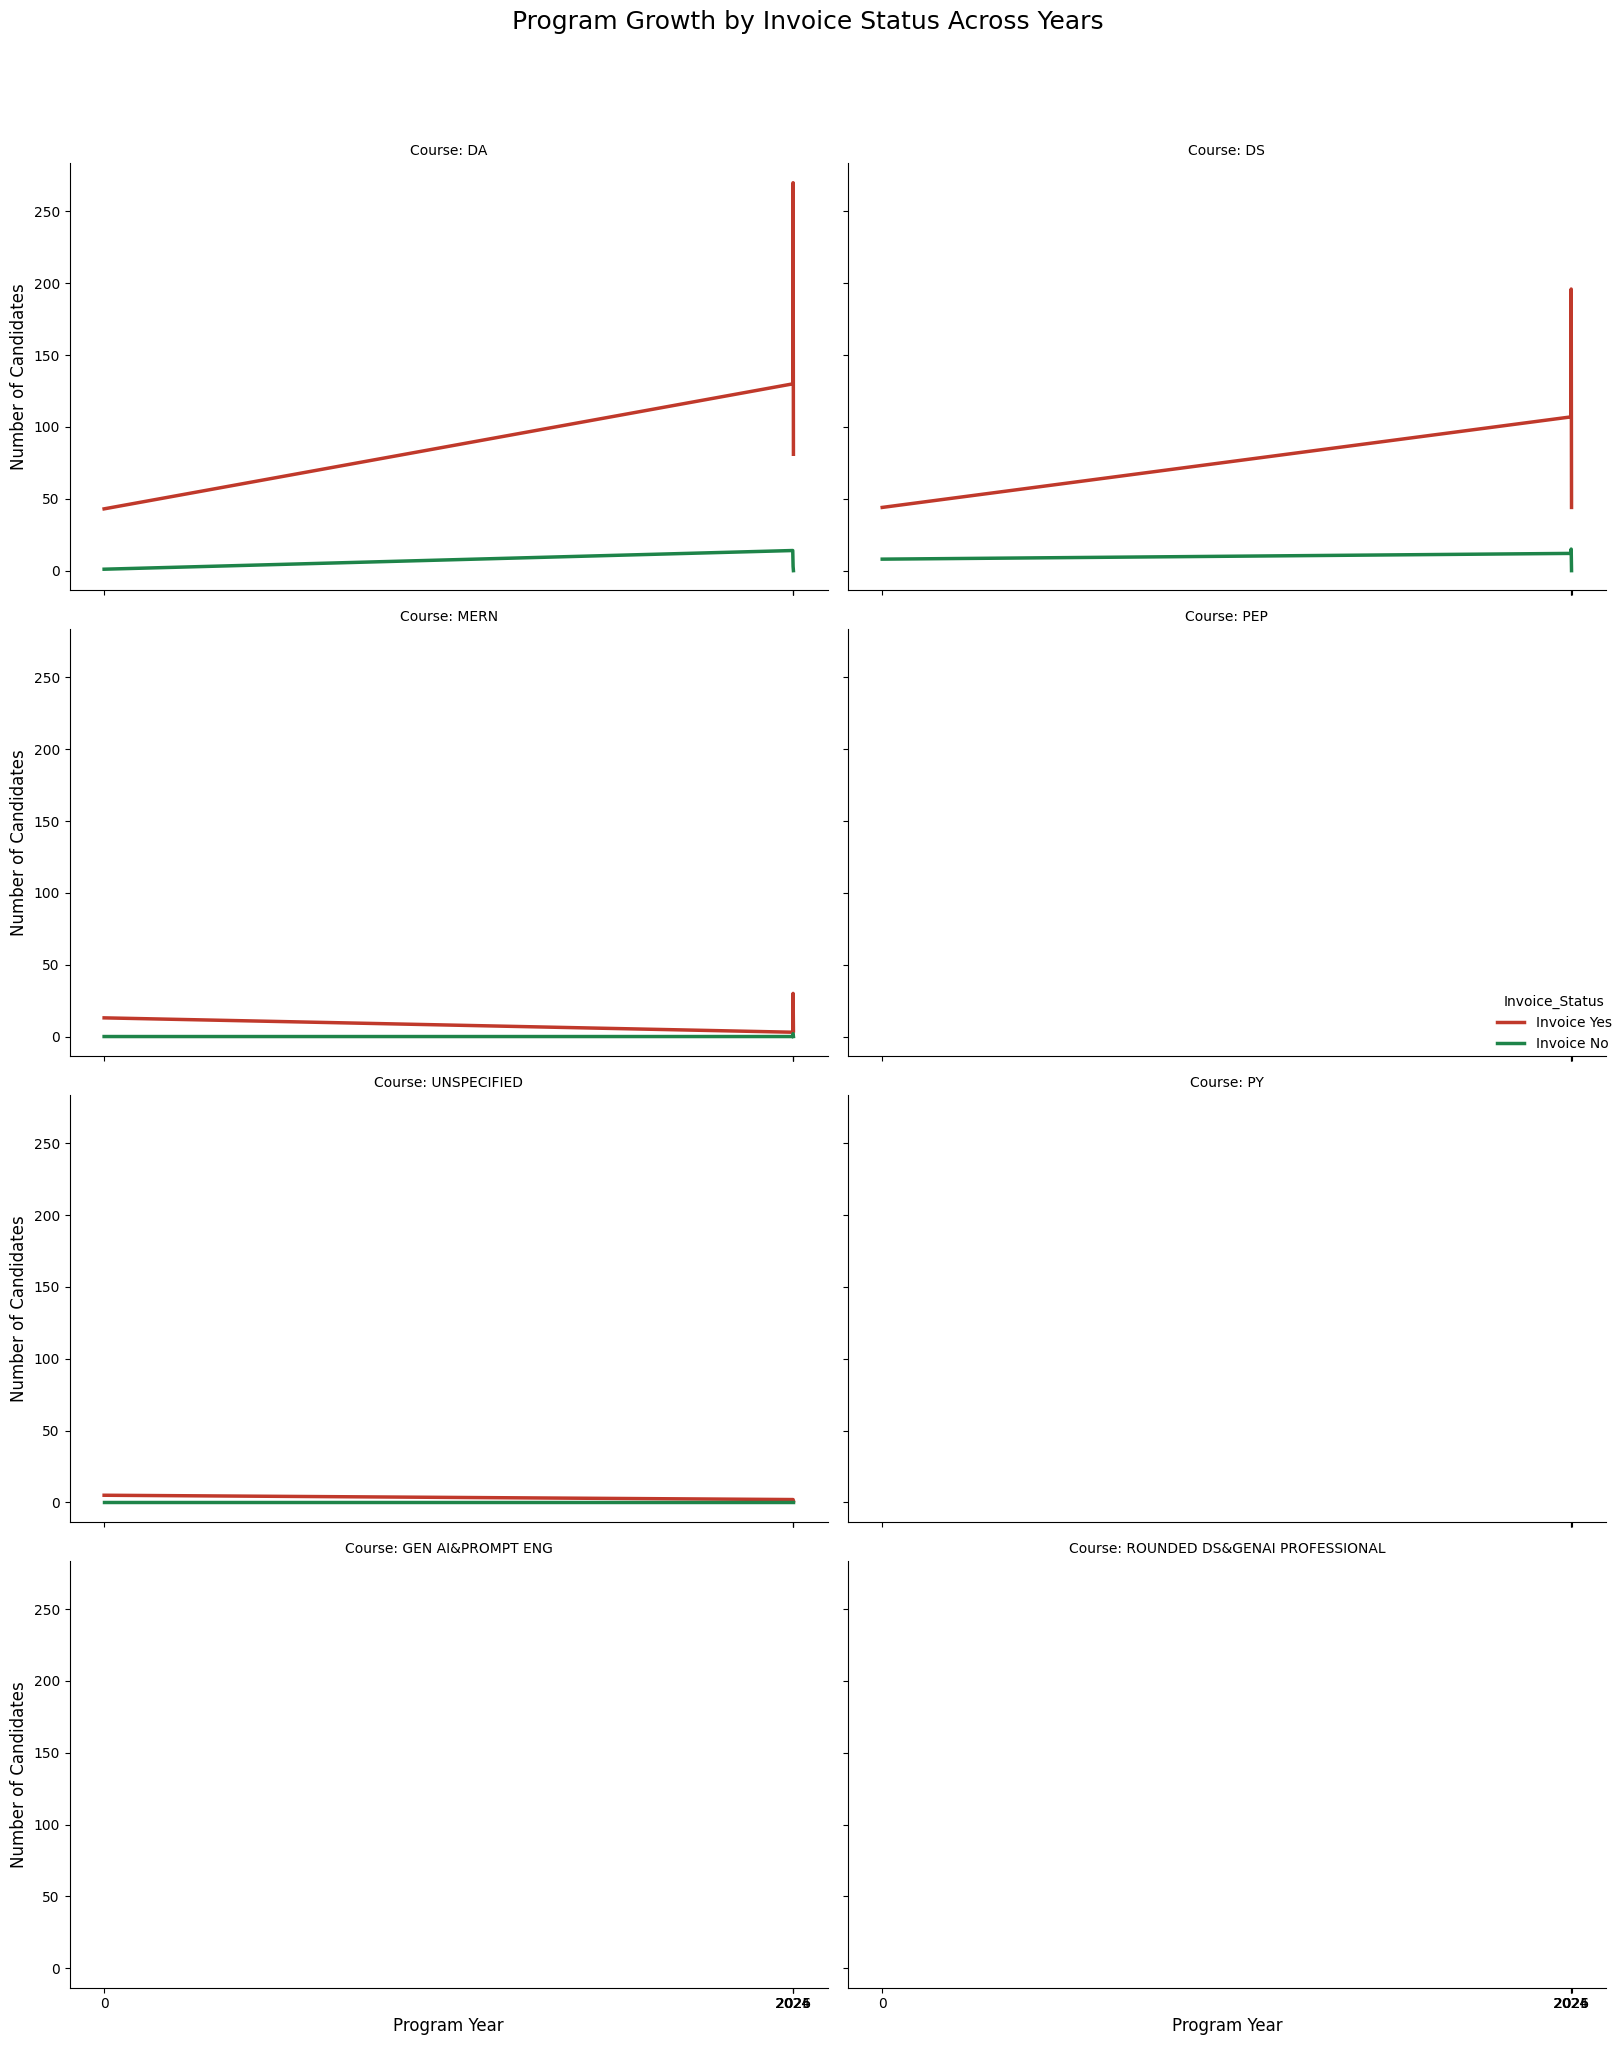

In [92]:
# Aggregate data by Program_Year, Course_Name, and Invoice status
program_year_invoice_counts = program_data_for_plot.groupby(['Program_Year', 'Program_Name', 'Invoice']).size().unstack(fill_value=0).reset_index()

# Rename columns for clarity in the plot
program_year_invoice_counts = program_year_invoice_counts.rename(columns={'Yes': 'Invoice_Yes_Count', 'No': 'Invoice_No_Count'})

# Melt the DataFrame to a long format suitable for line plotting with hue
plot_df_long = program_year_invoice_counts.melt(
    id_vars=['Program_Year', 'Program_Name'],
    value_vars=['Invoice_Yes_Count', 'Invoice_No_Count'],
    var_name='Invoice_Status_Raw',
    value_name='Count'
)

# Clean up Invoice_Status for better legend labels
plot_df_long['Invoice_Status'] = plot_df_long['Invoice_Status_Raw'].replace(
    {'Invoice_Yes_Count': 'Invoice Yes', 'Invoice_No_Count': 'Invoice No'}
)

# Create a faceted line plot with darker palette, thicker lines, and larger fonts
# Increased height and aspect for a larger plot size
g = sns.relplot(
    data=plot_df_long,
    x='Program_Year',
    y='Count',
    hue='Invoice_Status',
    col='Program_Name', # Facet by Course_Name to get one plot per program
    kind='line',
    col_wrap=2, # Wrap columns after 2 plots for even larger individual plot sizes
    height=5, aspect=1.5, # Adjusted for larger plot size
    palette={'Invoice Yes': '#C0392B', 'Invoice No': '#1E8449'}, # Darker, more distinct colors
    linewidth=2.5 # Make lines thicker
)

# Customize titles and labels with larger font sizes
g.set_axis_labels("Program Year", "Number of Candidates", fontsize=12)
g.set_titles("Course: {col_name}", fontsize=14)
g.fig.suptitle('Program Growth by Invoice Status Across Years', y=1.02, fontsize=18) # Increase super title font size

# Get unique years from the data to use as x-axis ticks
unique_program_years = sorted(plot_df_long['Program_Year'].unique())

# Set x-ticks for each subplot to display only whole years
for ax in g.axes.flat:
    ax.set_xticks(unique_program_years)
    ax.set_xticklabels([str(int(year)) for year in unique_program_years])

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()

### **Distribution of Candidates by Role**

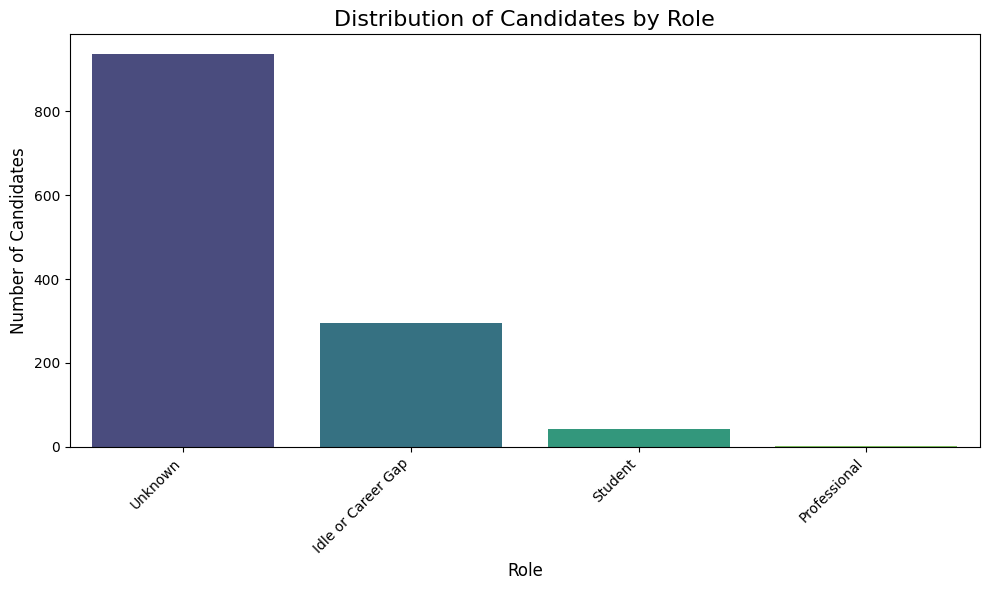

In [93]:
role_distribution = enrolled['role'].value_counts().reset_index()
role_distribution.columns = ['Role', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Role', y='Count', data=role_distribution, palette='viridis', hue='Role', legend=False)
plt.title('Distribution of Candidates by Role', fontsize=16)
plt.xlabel('Role', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Distribution of Candidates by Background (Tech/Non-Tech)**

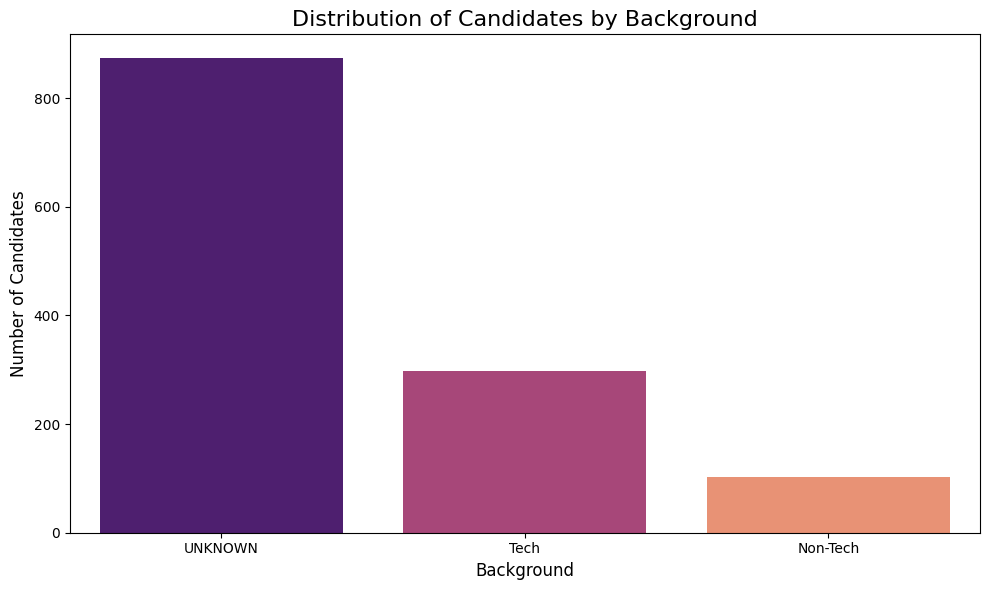

In [94]:
background_distribution = enrolled['background'].value_counts().reset_index()
background_distribution.columns = ['Background', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Background', y='Count', data=background_distribution, palette='magma', hue='Background', legend=False)
plt.title('Distribution of Candidates by Background', fontsize=16)
plt.xlabel('Background', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [95]:
print("\nTop Suggested Churn Reasons:")
display(inferred_reason_counts.head(10)) # Displaying the top 10 reasons


Top Suggested Churn Reasons:


,Reason,Count
0,Unreachable/Not Connected,4026
1,Already Working/Internship,1002
2,Decision Pending/Discussing,860
3,Not Interested,753
4,Joined Competitor,579
5,Looking for Job/Internship (Specific Type),489
6,Financial Issue,39
7,Looking for Other Opportunity (Not Interested),39
8,Location Issue,9
9,Time/Schedule Conflict,2


### **Churn by Candidate Source**

### **Active vs. Churned Candidates by Source of Lead**

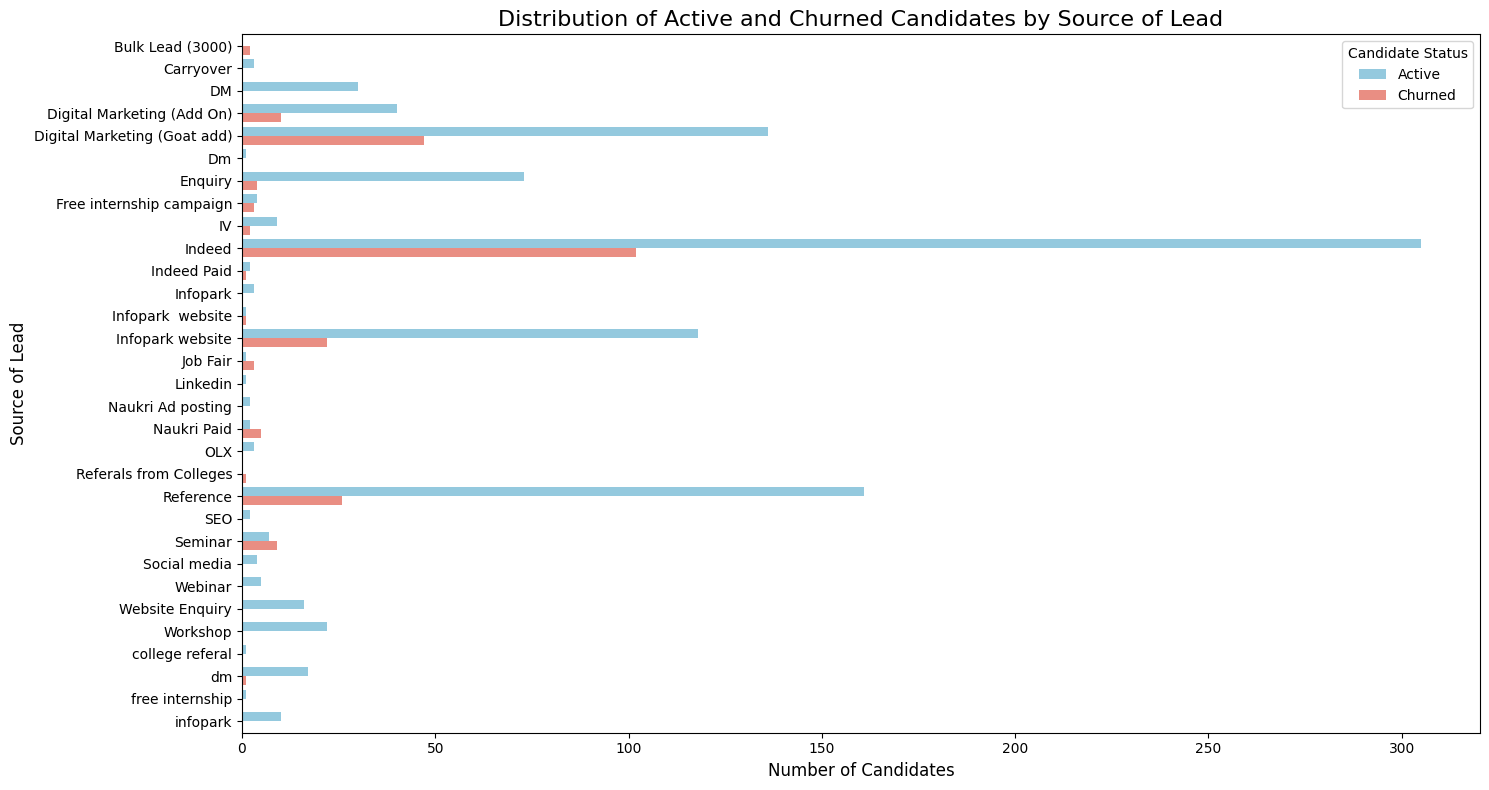

In [97]:
# Create a 'Status' column to differentiate between active and churned candidates
def get_status(row):
    if row['Program Joined'] != 'Not joined' and row['Invoice'] == 'Yes':
        return 'Active'
    elif row['Program Joined'] == 'Not joined': # Assuming all 'Not joined' are considered churned for this context
        return 'Churned'
    else:
        return 'Other/Not Classified' # Handle cases like 'Joined' but no invoice, if needed

enrolled['Status'] = enrolled.apply(get_status, axis=1)

# Filter for relevant statuses and group by source and status
churn_active_by_source = enrolled[enrolled['Status'].isin(['Active', 'Churned'])] \
                                .groupby(['Source of lead', 'Status']).size().unstack(fill_value=0).reset_index()

# Melt the DataFrame for easier plotting with seaborn
plot_df = churn_active_by_source.melt(id_vars='Source of lead', var_name='Status', value_name='Count')

plt.figure(figsize=(15, 8))
sns.barplot(x='Count', y='Source of lead', hue='Status', data=plot_df,
            palette={'Active': 'skyblue', 'Churned': 'salmon'})
plt.title('Distribution of Active and Churned Candidates by Source of Lead', fontsize=16)
plt.xlabel('Number of Candidates', fontsize=12)
plt.ylabel('Source of Lead', fontsize=12)
plt.legend(title='Candidate Status')
plt.tight_layout()
plt.show()

### **Training Mode of Churned and Active Candidates**

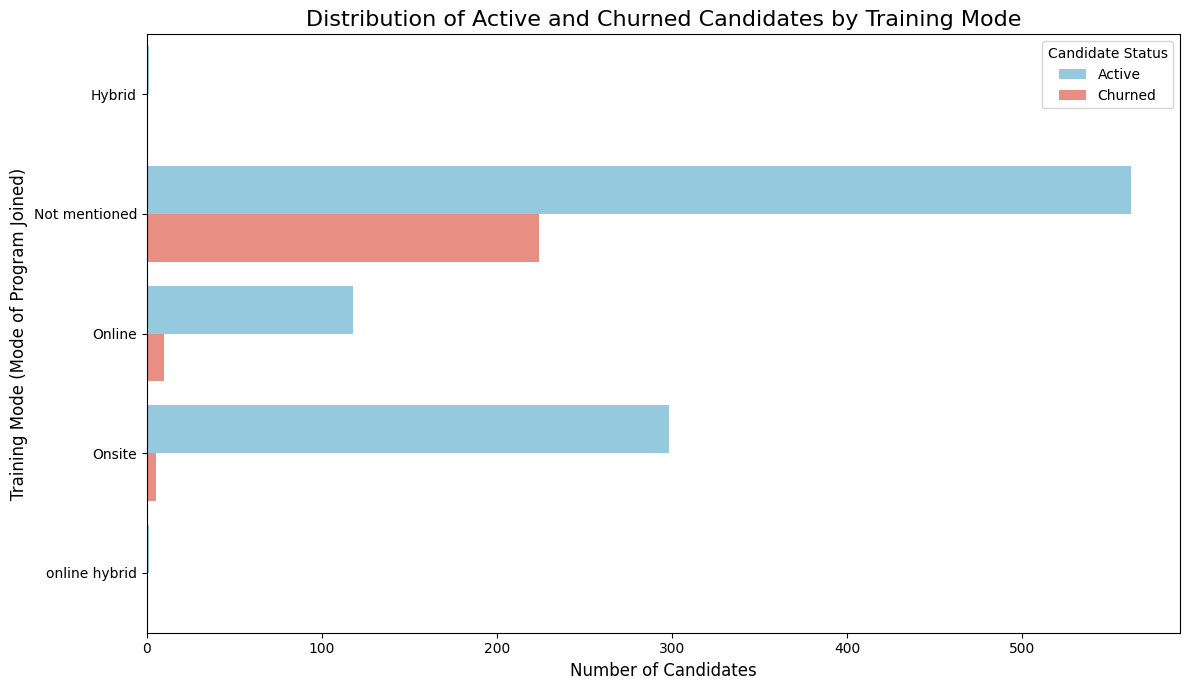

In [99]:
# Filter for active and churned candidates
active_churned_candidates = enrolled[enrolled['Status'].isin(['Active', 'Churned'])]

# Group by 'Mode of Program Joined' and 'Status'
churn_active_by_mode = active_churned_candidates.groupby(['Mode of Program Joined', 'Status']).size().unstack(fill_value=0).reset_index()

# Melt the DataFrame for easier plotting with seaborn
plot_df_mode = churn_active_by_mode.melt(id_vars='Mode of Program Joined', var_name='Status', value_name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Mode of Program Joined', hue='Status', data=plot_df_mode,
            palette={'Active': 'skyblue', 'Churned': 'salmon'})
plt.title('Distribution of Active and Churned Candidates by Training Mode', fontsize=16)
plt.xlabel('Number of Candidates', fontsize=12)
plt.ylabel('Training Mode (Mode of Program Joined)', fontsize=12)
plt.legend(title='Candidate Status')
plt.tight_layout()
plt.show()